#Part 0: Shared Game Engine

##Task: Implement the TicTacToe Class

In [ ]:
class TicTacToe:
  def __init__(self):

    # Initialize an empty 3x3 board.
    # Board is a list of 9 elements:
    # 0 = empty, 1 = X, -1 = O
    self.board: list[int] = [0] * 9

    # X always moves first.
    self.current_player: int = 1

  def get_legal_moves(self) -> list[int]:
    # Return a list of indices (0 through 8)
    # corresponding to the empty squares.
    moves: list[int] = []
    for i in range(9):
      if self.board[i] == 0:
        moves.append(i)

    return moves

  def make_move(self, move: int) -> 'TicTacToe':
    # Place the current player's mark at the
    # given index. Return a NEW TicTacToe
    # object; do not modify self.
    new_state = TicTacToe()
    new_state.board = list(self.board)
    new_state.board[move] = self.current_player
    new_state.current_player = -self.current_player
    return new_state

  def is_terminal(self) -> bool:
    # Return True if the game is over, either
    # because someone has won or because all
    # squares are filled (a draw).
    if self.check_winner() != 0:
        return True
    if 0 not in self.board:
        return True
    return False

  def utility(self) -> int:
    # Return +1 if X has won, -1 if O has won,
    # or 0 for a draw. Only valid when
    # is_terminal() returns True.
    return self.check_winner()

  def check_winner(self) -> int:
    # Return 1 if X has three in a row, -1 if
    # O has three in a row, or 0 otherwise.
    win_conditions = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8],  # Rows
        [0, 3, 6], [1, 4, 7], [2, 5, 8],  # Columns
        [0, 4, 8], [2, 4, 6]              # Diagonals
    ]
    for a, b, c in win_conditions:
        if self.board[a] != 0 and self.board[a] == self.board[b] == self.board[c]:
            return self.board[a]
    return 0

  def display(self) -> None:
    # Print the board in a readable 3x3 format.
    # Use 'X' for 1, 'O' for -1, '.' for 0.
    symbols = {1: 'X', -1: 'O', 0: '.'}
    for i in range(0, 9, 3):
        row = [symbols[self.board[j]] for j in range(i, i+3)]
        print(" " + " | ".join(row) + " ")
        if i < 6:
            print("---+---+---")

#Part 1: Minimax with Alpha-Beta Pruning

##Task: Implement Basic Minimax

In [ ]:
# These global counters track how many game states (nodes)
# the agent evaluates to compare efficiency
minimax_node_count: int = 0
alphabeta_node_count: int = 0

# The minimax function iterates through all possible moves from the root
# and picks whichever leads to the best possible outcome, assuming
# perfect play from both sides
def minimax(state: TicTacToe) -> int:

    global minimax_node_count
    minimax_node_count += 1

    # This conditional statement checks which logic to apply
    # depending on whose turn it is.
    # Player 1 is the maximizer and wants the highest score
    if state.current_player == 1:
        best_value = float('-inf')
        best_move = None

        # Iterate through every empty spot on the board to simulate a move
        for move in state.get_legal_moves():
            child = state.make_move(move)
            value = min_value(child)

            # Update the best move if the current branch yields a higher utility
            if value > best_value:
                best_value = value
                best_move = move
        return best_move

    # Player 2 is the minimizer and wants the the lowest score
    else:
        best_value = float('inf')
        best_move = None

        # Check all possible responses to find the one that hurts Player 1 the most
        for move in state.get_legal_moves():
            child = state.make_move(move)
            value = max_value(child)

            # Update the best move if this branch yields a lower utility
            if value < best_value:
                best_value = value
                best_move = move
        return best_move


# The maximizing player's logic.
# The AI looks at all possible responses using the max_value() function
# and returns the highest utility score possible from those branches.
def max_value(state: TicTacToe) -> int:

    global minimax_node_count
    minimax_node_count += 1

    # Base case: if the game is won, lost, or tied, the recursion ends
    if state.is_terminal():
        return state.utility()

    # Explores the entire depth of the game tree from this point forward
    v = float('-inf')
    for move in state.get_legal_moves():
        child = state.make_move(move)
        v = max(v, min_value(child))
    return v


# The minimizing player's logic. It returns the lowest possible
# utility it can find from the maximizer's subsequent moves.
def min_value(state: TicTacToe) -> int:

    global minimax_node_count
    minimax_node_count += 1

    # Base case
    if state.is_terminal():
        return state.utility()

    # Simulates every possible move the minimizer could make
    v = float('inf')
    for move in state.get_legal_moves():
        child = state.make_move(move)
        v = min(v, max_value(child))
    return v

In [ ]:
import sys

# improved no duplicated code
# uses sys.maxsize instead of float('inf')
# uses 2 functions only much simpler

def better_minimax(state: TicTacToe) -> int:
  global minimax_node_count
  minimax_node_count += 1

  _ , best_move = better_minimax_helper(state)
  return best_move

def better_minimax_helper(state: TicTacToe) -> tuple[int, int]:

    global minimax_node_count
    minimax_node_count += 1

    best_move = -1
    best_value = -sys.maxsize * state.current_player

    if state.is_terminal():
        return state.utility(), -1

    for move in state.get_legal_moves():
        child = state.make_move(move)
        potential_value, _ = better_minimax_helper(child)

        if state.current_player == 1:
            if potential_value > best_value:
                best_value = potential_value
                best_move = move
        else:
            if potential_value < best_value:
                best_value = potential_value
                best_move = move

    return best_value, best_move

##Task: Add Alpha-Beta Pruning

In [ ]:
# The alphabeta() function decides the best move using alpha and beta thresholds
# down the tree, which allows the agent to ignore branches that don't change
# the final decision, reducing computation as a result
def alphabeta(state: TicTacToe) -> int:

    global alphabeta_node_count
    alphabeta_node_count += 1

    alpha = float('-inf') # Best already explored for Maximizer
    beta = float('inf')   # Best already explored for Minimizer

    # Primary split between the maximizing and minimizing agents
    if state.current_player == 1:
        best_value = float('-inf')
        best_move = None

        # Scans all legal moves while carrying the alpha/beta thresholds
        for move in state.get_legal_moves():
            child = state.make_move(move)
            value = min_value_ab(child, alpha, beta)
            if value > best_value:
                best_value = value
                best_move = move

            # Alpha is updated to represent the best score the Maximizer is guaranteed so far
            alpha = max(alpha, best_value)
        return best_move
    else:
        best_value = float('inf')
        best_move = None
        for move in state.get_legal_moves():
            child = state.make_move(move)
            value = max_value_ab(child, alpha, beta)
            if value < best_value:
                best_value = value
                best_move = move
            # Beta is updated to represent the lowest score the Minimizer is guaranteed so far
            beta = min(beta, best_value)
        return best_move

# This function explores moves for the Maximizer but checks if the current
# score (v) is already better than what the Minimizer has guaranteed
# elsewhere (beta). If it is, it prunes the branch
def max_value_ab(state: TicTacToe, alpha: int, beta: int) -> int:
    global alphabeta_node_count
    alphabeta_node_count += 1
    if state.is_terminal():
        return state.utility()

    v = float('-inf')
    for move in state.get_legal_moves():
        child = state.make_move(move)
        v = max(v, min_value_ab(child, alpha, beta))
        if v >= beta: # Pruning condition
            return v
        alpha = max(alpha, v)
    return v

# This function explores moves for the Minimizer but checks if the current
# score (v) is already lower than what the Maximizer has guaranteed
# elsewhere (alpha). If so, it abandons the rest of the search in this branch.
def min_value_ab(state: TicTacToe, alpha: int, beta: int) -> int:

    global alphabeta_node_count
    alphabeta_node_count += 1
    if state.is_terminal():
        return state.utility()

    v = float('inf')
    for move in state.get_legal_moves():
        child = state.make_move(move)
        v = min(v, max_value_ab(child, alpha, beta))
        if v <= alpha: # Pruning condition
            return v
        beta = min(beta, v)
    return v

In [ ]:
def better_alphabeta(state: TicTacToe) -> int:
    global alphabeta_node_count
    alphabeta_node_count = 0  # Reset count each call

    alpha = -sys.maxsize
    beta = sys.maxsize
    _, best_move = better_alphabeta_helper(state, alpha, beta)
    return best_move

def better_alphabeta_helper(state: TicTacToe, alpha: int, beta: int) -> tuple[int, int]:
    global alphabeta_node_count
    alphabeta_node_count += 1

    if state.is_terminal():
        return state.utility(), -1

    best_move = -1
    # -inf for Maximizer, +inf for Minimizer
    best_value = -sys.maxsize * state.current_player

    for move in state.get_legal_moves():
        child = state.make_move(move)
        potential_value, _ = better_alphabeta_helper(child, alpha, beta)

        if state.current_player == 1:  # Maximizer (X)
            if potential_value > best_value:
                best_value = potential_value
                best_move = move
            if best_value >= beta:
                return best_value, best_move
            alpha = max(alpha, best_value)

        else:  # Minimizer (O)
            if potential_value < best_value:
                best_value = potential_value
                best_move = move
            if best_value <= alpha:
                return best_value, best_move
            beta = min(beta, best_value)

    return best_value, best_move


##Task: Count Nodes and Compare

In [ ]:
if __name__ == "__main__":
    # Initialize an entirely empty board
    game: TicTacToe = TicTacToe()

    # Reset global counters before running
    minimax_node_count = 0
    alphabeta_node_count = 0

    print("Initial Board State:")
    game.display()
    print("\nRunning standard minimax... (this may take a few seconds)")

    # Run standard Minimax
    mm_move: int = better_minimax(game)

    print("Running alpha-beta pruning...")

    # Run Alpha-Beta Pruning
    ab_move: int = better_alphabeta(game)

    # Calculate stats
    pruned_nodes = minimax_node_count - alphabeta_node_count
    percentage_pruned = (pruned_nodes / minimax_node_count) * 100

    # Report exactly as requested
    print("\n" + "="*40)
    print("RESULTS:")
    print("="*40)
    print(f"1. The total number of nodes evaluated by plain minimax: {minimax_node_count:,}")
    print(f"2. The total number of nodes evaluated by alpha-beta: {alphabeta_node_count:,}")
    print(f"3. The percentage of nodes pruned: {percentage_pruned:.2f}%\n")

    empty_game: TicTacToe = game.make_move(0)
    empty_game.display()
    ckeck: bool = empty_game.board[0] == 1
    print(f"\nFrom the empty board, minimax for X should return to a corner or the center. {ckeck}\n")

    new_game = game.make_move(4)
    new_game = new_game.make_move(8)
    ab_move: int = better_alphabeta(new_game)
    new_game = new_game.make_move(ab_move)
    new_game.display()
    ckeck: bool = new_game.board[0] == 1
    print(f"\nIf X plays center and O plays a corner, X should respond with the opposite corner. {ckeck}\n")

    while game.is_terminal() == False:
        move = better_alphabeta(game)
        game = game.make_move(move)

    game.display()
    check = game.check_winner() == 0 # a tie

    print(f"\nTwo minimax agents playing with each other should always draw. {check}\n")



Initial Board State:
 . | . | . 
---+---+---
 . | . | . 
---+---+---
 . | . | . 

Running standard minimax... (this may take a few seconds)
Running alpha-beta pruning...

RESULTS:
1. The total number of nodes evaluated by plain minimax: 549,947
2. The total number of nodes evaluated by alpha-beta: 18,297
3. The percentage of nodes pruned: 96.67%

 X | . | . 
---+---+---
 . | . | . 
---+---+---
 . | . | . 

From the empty board, minimax for X should return to a corner or the center. True

 X | . | . 
---+---+---
 . | X | . 
---+---+---
 . | . | O 

If X plays center and O plays a corner, X should respond with the opposite corner. True

 X | X | O 
---+---+---
 O | O | X 
---+---+---
 X | O | X 

Two minimax agents playing with each other should always draw. True



#Part 2: Monte Carlo Tree Search

##Task: Implement the MCTS Node

In [ ]:
import math
import random
from typing import Optional

class MCTSNode:
    def __init__(self, state: TicTacToe, parent: Optional['MCTSNode'] = None, move: Optional[int] = None):
        self.state = state
        self.parent = parent
        self.move = move
        self.children: list['MCTSNode'] = []
        self.wins = 0
        self.visits = 0
        self.untried_moves = state.get_legal_moves()

    def is_fully_expanded(self) -> bool:
        # Return True if every legal move from
        # this state has a corresponding child.

        # Since we pop/remove moves from untried_moves when we create
        # a new child, the node is fully expanded when this list is empty.
        return len(self.untried_moves) == 0

    def best_child(self, c: float = 1.41) -> Optional['MCTSNode']:
        # Return the child with the highest UCB1
        # score. Use the formula from Section 5.4.
        best_score: float = float('-inf')
        best_node: Optional['MCTSNode'] = None

        for child in self.children:
            # If a child somehow has 0 visits, it has infinite exploration value.
            # (In standard MCTS, best_child is usually only called on fully expanded nodes)
            if child.visits == 0:
                return child

            # UCB1 Calculation
            exploit: float = child.wins / child.visits
            explore: float = c * math.sqrt(math.log(self.visits) / child.visits)
            ucb1_score: float = exploit + explore

            if ucb1_score > best_score:
                best_score = ucb1_score
                best_node = child

        return best_node

    def best_move(self) -> Optional[int]:
        # Return the move leading to the child
        # with the most visits (not the highest
        # win rate).
        if not self.children:
            return None

        # max() makes it easy to find the child with the highest visit count
        most_visited_child = max(self.children, key=lambda child: child.visits)
        return most_visited_child.move

##Task: Implement the Four Steps

###Selection

In [ ]:
def select(node: MCTSNode) -> Optional[MCTSNode]:
    # Starting from the given node, repeatedly
    # choose the best child (by UCB1) until you
    # reach a node that is not fully expanded
    # or that represents a terminal state.

    while node.is_fully_expanded() and not node.state.is_terminal():
        node = node.best_child()

    return node

###Expansion

In [ ]:
def expand(node: MCTSNode) -> MCTSNode:
    # Choose one of the untried moves, create a
    # new child node for it, and return the child.

    # Randomly select an untried move and remove it from the list
    # (This ensures we eventually try all moves and triggers is_fully_expanded)
    move: int = random.choice(node.untried_moves)
    node.untried_moves.remove(move)

    # Generate the new game state that results from this move
    new_state: TicTacToe = node.state.make_move(move)

    # Create the child node.
    # Pass the new state, the current node as the parent, and the move used.
    child_node: MCTSNode = MCTSNode(state=new_state, parent=node, move=move)

    # Add the newly created child to the parent's list of children
    node.children.append(child_node)


    return child_node

###Simulation

In [ ]:
def simulate(state: TicTacToe) -> int:
    # From the given state, play a random game to
    # completion. At each step, choose a uniformly
    # random legal move. Return the utility.

    # Keep playing random moves until someone wins or it's a draw
    while not state.is_terminal():
        possible_moves: list[int] = state.get_legal_moves()
        move: int = random.choice(possible_moves)

        # Advance the simulation to the next state
        state: TicTacToe = state.make_move(move)

    # The game is over. Return the result (+1, -1, or 0)
    return state.utility()

###Back-propagation

In [ ]:
def backpropagate(node: MCTSNode, result: int) -> None:
    # Walk from the given node up to the root.
    # Increment the visit count of every node.
    # Increment the win count only for nodes
    # where the result was favorable for the
    # player who made the move.

    while node is not None:
        node.visits += 1

        # The player who made the move to reach this specific node
        # is the opposite of the player whose turn it is currently.
        player_who_moved: int = -node.state.current_player

        # If the result (+1 for X, -1 for O) matches the player
        # who made the move, it was a winning simulation for them.
        if result == player_who_moved:
            node.wins += 1

        # (Optional but common: You could add an `elif result == 0:` here
        # and add 0.5 to `node.wins` so the AI prefers draws over losses.)

        # Move one step up the tree
        node = node.parent

##Task: Implement the Main Loop

In [ ]:
def mcts(state: MCTSNode, iterations: int = 10) -> int:
    root = MCTSNode(state)
    for _ in range(iterations):
        # 1. Select
        leaf: MCTSNode = select(root)
        # 2. Expand (if not terminal)
        if not leaf.state.is_terminal():
            leaf = expand(leaf)
        # 3. Simulate
        result: int = simulate(leaf.state)
        # 4. Back-propagate
        backpropagate(leaf, result)
        print(f"")
    return root.best_move()



##Task: Verify Correctness

In [ ]:
import unittest
import random

# --- VERIFICATION TEST SUITE ---

class TestMCTS(unittest.TestCase):

    def setUp(self):
        # Fix the random seed so our tests are fully deterministic and reproducible
        random.seed(42)


    def test_expansion_mechanics(self):
        # Test that expansion properly shrinks untried_moves and adds children
        game: TicTacToe = TicTacToe()
        root: MCTSNode = MCTSNode(state=game)

        initial_moves_count = len(root.untried_moves)
        self.assertFalse(root.is_fully_expanded())

        # Expand once
        child: MCTSNode = expand(root)

        self.assertEqual(len(root.untried_moves), initial_moves_count - 1)
        self.assertEqual(len(root.children), 1)
        self.assertIs(child.parent, root)
        self.assertEqual(child.state.current_player, -1) # Turn should swap




    def test_backpropagation_math(self):
        # Test that visits and wins correctly propagate up the tree
        game: TicTacToe = TicTacToe()
        root: MCTSNode = MCTSNode(state=game)

        # Manually construct a child node where Player 1 just moved
        child_state: TicTacToe = game.make_move(0)
        child: MCTSNode = MCTSNode(state=child_state, parent=root, move=0)

        # Simulate a result where Player 1 won (result = 1)
        backpropagate(child, result=1)

        # Root should have 1 visit.
        self.assertEqual(root.visits, 1)

        # Child should have 1 visit and 1 win
        self.assertEqual(child.visits, 1)
        self.assertEqual(child.wins, 1)



    def test_find_winning_move(self):
        # Integration Test: MCTS should find an immediate winning move
        game: TicTacToe = TicTacToe()
        game.board = [
             1,  1,  0,
            -1, -1,  0,
             0,  0,  0
        ]
        game.current_player = 1

        # Move 2 wins the game immediately for X.
        best_move: int = mcts(game, iterations=1000)

        self.assertEqual(best_move, 2, "MCTS failed to find the winning move")



    def test_block_losing_move(self):
        # Integration Test: MCTS should block the opponent from winning
        game: TicTacToe = TicTacToe()
        game.board = [
             1,  1,  0,
             0, -1,  0,
             0,  0,  0
        ]
        game.current_player = -1

        best_move = mcts(game, iterations=2000)


        self.assertEqual(best_move, 2, "MCTS failed to block the opponent's win")



if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)



....
----------------------------------------------------------------------
Ran 4 tests in 0.077s

OK


#Part 3: Head-to-Head Comparison

In [ ]:
import random
from abc import ABC, abstractmethod

class Agent(ABC):
  @staticmethod
  @abstractmethod
  def play(state: TicTacToe)  -> int:
      pass

  @staticmethod
  @abstractmethod
  def get_name(char: str) -> str:
      pass

class RandomAgent(Agent):
    @staticmethod
    def play(state: TicTacToe) -> int:
      return random.choice(state.get_legal_moves())

    @staticmethod
    def get_name(char: str) -> str:
        return f"Random ({char})"

class MinimaxAgent(Agent):
    @staticmethod
    def play(state: TicTacToe) -> int:
        return better_alphabeta(state)

    @staticmethod
    def get_name(char: str) -> str:
        return f"Minimax ({char})"

class MCTSAgent(Agent):
    @staticmethod
    def play(state: TicTacToe) -> int:
        return mcts(state, iterations=1000)

    @staticmethod
    def get_name(char: str) -> str:
        return f"MCTS ({char})"

In [ ]:
import random
from abc import ABC, abstractmethod

class PerfectAgent(Agent):
    # Newell and Simon Method for the perfect moves
    @staticmethod
    def play(state: TicTacToe) -> int:
        win_conditions = [
            [0, 1, 2], [3, 4, 5], [6, 7, 8],  # Rows
            [0, 3, 6], [1, 4, 7], [2, 5, 8],  # Columns
            [0, 4, 8], [2, 4, 6]              # Diagonals
        ]

        def count_threats(board_state: list[int], player: int) -> int:
            threats = 0
            for a, b, c in win_conditions:
                line = [board_state[a], board_state[b], board_state[c]]
                if line.count(player) == 2 and line.count(0) == 1:
                    threats += 1
            return threats

        legal_moves = state.get_legal_moves()
        if not legal_moves:
            return -1

        # 1. Win
        win_move = PerfectAgent.checkImm8Win(state, state.current_player)
        if win_move != -1:
            return win_move

        # 2. Block
        block_move = PerfectAgent.checkImm8Win(state, -state.current_player)
        if block_move != -1:
            return block_move

        # 3. Fork: Simulate each move to see if it creates 2 or more threats
        for move in legal_moves:
            state.board[move] = state.current_player
            if count_threats(state.board, state.current_player) >= 2:
                state.board[move] = 0
                return move
            state.board[move] = 0

        # 4. Block Opponent Fork
        opponent_forks = []
        for move in legal_moves:
            state.board[move] = -state.current_player
            if count_threats(state.board, -state.current_player) >= 2:
                opponent_forks.append(move)
            state.board[move] = 0

        if opponent_forks:
            if len(opponent_forks) == 1:
                return opponent_forks[0]
            else:
                for move in legal_moves:
                    state.board[move] = state.current_player
                    my_threat_idx = PerfectAgent.checkImm8Win(state, state.current_player)
                    state.board[move] = 0

                    if my_threat_idx != -1 and my_threat_idx not in opponent_forks:
                        return move

        # 5. Center
        if state.board[4] == 0:
            return 4

        # 6. Opposite Corner
        opposite_corners_map = {0: 8, 2: 6, 6: 2, 8: 0}
        for corner_idx, opp_idx in opposite_corners_map.items():
            if state.board[corner_idx] == -state.current_player and state.board[opp_idx] == 0:
                return opp_idx

        # 7. Empty Corner
        for corner_idx in [0, 2, 6, 8]:
            if state.board[corner_idx] == 0:
                return corner_idx

        # 8. Empty Side
        for side_idx in [1, 3, 5, 7]:
            if state.board[side_idx] == 0:
                return side_idx

        return legal_moves[0]

    @staticmethod
    def checkImm8Win(state: TicTacToe, player: int) -> int:
        win_conditions = [
            [0, 1, 2], [3, 4, 5], [6, 7, 8],
            [0, 3, 6], [1, 4, 7], [2, 5, 8],
            [0, 4, 8], [2, 4, 6]
        ]
        for a, b, c in win_conditions:
            line = [state.board[a], state.board[b], state.board[c]]
            if line.count(player) == 2 and line.count(0) == 1:
                # Return the index of the 0
                return [x for x in (a, b, c) if state.board[x] == 0][0]
        return -1

    @staticmethod
    def get_name(char: str) -> str:
        return f"Perfect ({char})"

##Task: Build a Tournament

In [ ]:
from collections import defaultdict

matchups: list[Agent] = [MinimaxAgent(), PerfectAgent(), RandomAgent(), MCTSAgent()]
scoreboard: defaultdict[str, dict[str, int]] = defaultdict(lambda: {"wins": 0, "ties": 0, "losses": 0})

def play_matchup(player_x: Agent, player_o: Agent, games: int = 100) -> tuple[int, int, int]:
    x_wins = 0
    o_wins = 0
    draws = 0
    for _ in range(games):
        game = TicTacToe()
        while not game.is_terminal():
            move = player_x.play(game) if game.current_player == 1 else player_o.play(game)
            game = game.make_move(move)
        res = game.utility()
        if res == 1: x_wins += 1
        elif res == -1: o_wins += 1
        else: draws += 1

    label = f"{player_x.get_name('X')} vs {player_o.get_name('O')}"
    print(f"{label:<30} | {x_wins:<8} | {o_wins:<8} | {draws:<6}")

    x_name = player_x.get_name('')
    o_name = player_o.get_name('')
    scoreboard[x_name]["wins"] += x_wins
    scoreboard[x_name]["losses"] += o_wins
    scoreboard[x_name]["ties"] += draws

    scoreboard[o_name]["wins"] += o_wins
    scoreboard[o_name]["losses"] += x_wins
    scoreboard[o_name]["ties"] += draws
    return x_wins, o_wins, draws

if __name__ == '__main__':
    print(f"{'Matchup':<30} | {'X Wins':<8} | {'O Wins':<8} | {'Draws':<6}")

    for i in range(len(matchups)):
        for j in range(i + 1, len(matchups)):
          x_agent = matchups[i]
          o_agent = matchups[j]

          play_matchup(x_agent, o_agent, games=100)
          play_matchup(o_agent, x_agent, games=100)


Streaming output truncated to the last 5000 lines.























































































































































































































































































































































































































































































































































































































































































































































































































































































































































































In [ ]:
def print_leaderboard(stats: defaultdict[str, dict[str, int]]) -> None:
    # Calculate scores and win/loss ratio while sorting
    # Win = 3, Tie = 1, Lost = 0

    def get_score(data):
        return (data['wins'] * 3) + (data['ties'] * 1)

    def get_ratio(data):
        # Prevent division by zero if they have no losses
        return data['wins'] / data['losses'] if data['losses'] > 0 else float(data['wins'])

    # Sort players by descending score
    sorted_players = sorted(stats.items(), key=lambda x: get_score(x[1]), reverse=True)

    print(f"{'Player':<15} | {'Score':<6} | {'W':<3} | {'T':<3} | {'L':<3} | {'W/L Ratio'}")
    print("-" * 55)

    for player, data in sorted_players:
        score = get_score(data)
        ratio = get_ratio(data)
        print(f"{player:<15} | {score:<6} | {data['wins']:<3} | {data['ties']:<3} | {data['losses']:<3} | {ratio:.2f}")

print_leaderboard(scoreboard)

Player          | Score  | W   | T   | L   | W/L Ratio
-------------------------------------------------------
Perfect ()      | 1162   | 281 | 319 | 0   | 281.00
Minimax ()      | 986    | 193 | 407 | 0   | 193.00
MCTS ()         | 853    | 189 | 286 | 125 | 1.51
Random ()       | 65     | 3   | 56  | 541 | 0.01


##Task: Measure Execution Time

Streaming output truncated to the last 5000 lines.























































































































































































































































































































































































































































































































































































































































































































































































































































































































































































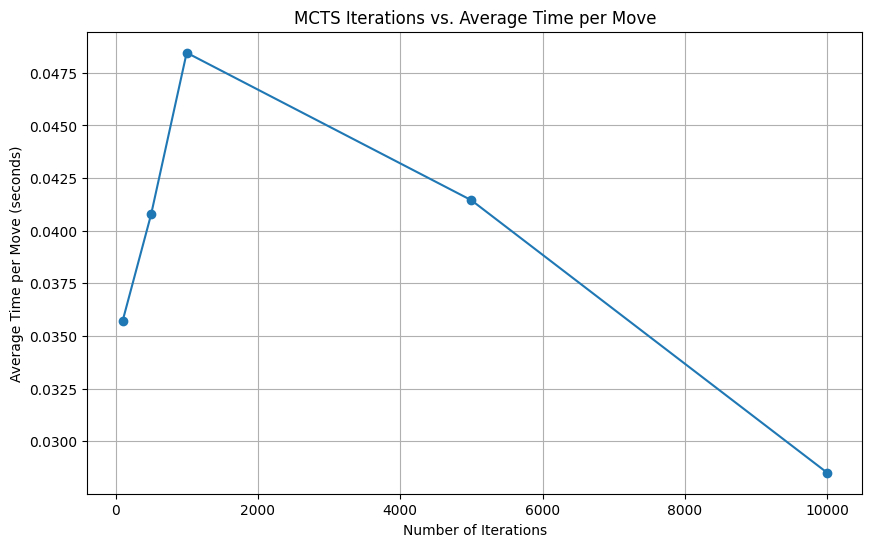

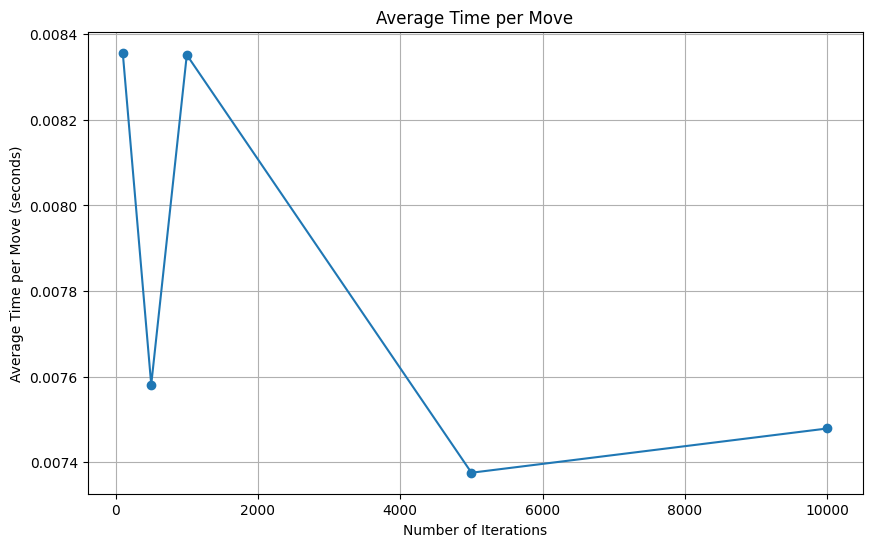

In [ ]:
import time
import matplotlib.pyplot as plt

def measure_agent_time(agent: Agent, iterations: int = 10, to_print: bool = True) -> float:
    game = TicTacToe()
    move_times = []
    while not game.is_terminal():
        start_time = time.time()
        move = agent.play(game)
        end_time = time.time()
        move_times.append(end_time - start_time)
        game = game.make_move(move)

    avg_time = sum(move_times) / len(move_times)
    if to_print:
      print(f"{agent.get_name(str(iterations))}: {avg_time:.6f}s")
    return avg_time

print("Average Time per Move:")

for agent in matchups:
    measure_agent_time(agent)

mcts_counts: list[int] = [100, 500, 1000, 5000, 10000]
avg_times: list[int] = []
for count in mcts_counts:
    t = measure_agent_time(MCTSAgent(), count, False)
    avg_times.append(t)

plt.figure(figsize=(10, 6))
plt.plot(mcts_counts, avg_times, marker='o')
plt.title('MCTS Iterations vs. Average Time per Move')
plt.xlabel('Number of Iterations')
plt.ylabel('Average Time per Move (seconds)')
plt.grid(True)
plt.show()


avg_times: list[int] = []
minMax_counts: list[int] = [100, 500, 1000, 5000, 10000]
for count in minMax_counts:
    t = measure_agent_time(MinimaxAgent(), count, False)
    avg_times.append(t)

plt.figure(figsize=(10, 6))
plt.plot(minMax_counts, avg_times, marker='o')
plt.title('Average Time per Move')
plt.xlabel('Number of Iterations')
plt.ylabel('Average Time per Move (seconds)')
plt.grid(True)
plt.show()